In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# LOAD DATA

In [2]:
train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df = pd.read_csv("mitbih_test.csv", header=None)

df = pd.concat([train_df, test_df])
df = df.sample(frac=1, random_state=42)

In [3]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Class weights (important for imbalance)
classes = np.unique(y)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weights = dict(zip(classes, weights))

# Reshape
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
df.isnull().sum()
df = df.fillna(0)
print(df.isnull().sum())

0      0
1      0
2      0
3      0
4      0
      ..
183    0
184    0
185    0
186    0
187    0
Length: 188, dtype: int64


In [5]:
X = df.iloc[:, :-1].to_numpy(dtype=np.float32)
y = df.iloc[:, -1].to_numpy()

# FEATURE EXTRACTION

In [6]:
from scipy.stats import skew, kurtosis
def extract_stat_features(signal):
    signal = np.array(signal, dtype=np.float32)

    return [
        np.mean(signal),
        np.std(signal),
        np.var(signal),
        np.min(signal),
        np.max(signal),
        np.sum(signal ** 2),
        np.sqrt(np.mean(signal ** 2)),
        skew(signal),
        kurtosis(signal)
    ]

X_stat = np.array([extract_stat_features(x) for x in X])

print("Stat feature shape:", X_stat.shape)

Stat feature shape: (109446, 9)


In [7]:
def cnn_block(input_layer):
    x = Conv1D(64, 5, padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(128, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(256, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(2)(x)

    x = Dropout(0.4)(x)
    return x

# CNN+LSTM

In [8]:
input_layer = Input(shape=(X.shape[1], 1))

x = cnn_block(input_layer)
x = LSTM(64)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(5, activation='softmax')(x)

model_lstm = Model(input_layer, output)

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(patience=7, restore_best_weights=True),
        ReduceLROnPlateau(patience=3)
    ]
)
model_lstm.save("model_lstm.h5")

Epoch 1/40
1095/1095 [==============================] - 193s 172ms/step - loss: 0.9584 - accuracy: 0.4604 - val_loss: 0.6451 - val_accuracy: 0.7767 - lr: 0.0010
Epoch 2/40
1095/1095 [==============================] - 241s 220ms/step - loss: 0.5835 - accuracy: 0.7062 - val_loss: 0.6125 - val_accuracy: 0.7477 - lr: 0.0010
Epoch 3/40
1095/1095 [==============================] - 242s 221ms/step - loss: 0.5056 - accuracy: 0.7639 - val_loss: 0.6721 - val_accuracy: 0.7655 - lr: 0.0010
Epoch 4/40
1095/1095 [==============================] - 245s 224ms/step - loss: 0.4377 - accuracy: 0.7974 - val_loss: 0.4344 - val_accuracy: 0.8687 - lr: 0.0010
Epoch 5/40
1095/1095 [==============================] - 221s 202ms/step - loss: 0.4183 - accuracy: 0.8170 - val_loss: 0.4171 - val_accuracy: 0.8668 - lr: 0.0010
Epoch 6/40
1095/1095 [==============================] - 142s 129ms/step - loss: 0.3781 - accuracy: 0.8249 - val_loss: 0.3388 - val_accuracy: 0.8989 - lr: 0.0010
Epoch 7/40
1095/1095 [============

# CNN+BiLSTM

In [29]:
input_layer = Input(shape=(X.shape[1], 1))

x = cnn_block(input_layer)
x = Bidirectional(LSTM(128))(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(5, activation='softmax')(x)

model_bilstm = Model(input_layer, output)

model_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(patience=7, restore_best_weights=True),
        ReduceLROnPlateau(patience=3)
    ]
)
model_bilstm.save("model_bilstm.h5")

Epoch 1/40
1095/1095 [==============================] - 159s 142ms/step - loss: 0.7479 - accuracy: 0.5433 - val_loss: 0.6762 - val_accuracy: 0.7439 - lr: 5.0000e-04
Epoch 2/40
1095/1095 [==============================] - 160s 146ms/step - loss: 0.4860 - accuracy: 0.7487 - val_loss: 0.6429 - val_accuracy: 0.7621 - lr: 5.0000e-04
Epoch 3/40
1095/1095 [==============================] - 162s 148ms/step - loss: 0.4343 - accuracy: 0.7917 - val_loss: 0.6443 - val_accuracy: 0.7416 - lr: 5.0000e-04
Epoch 4/40
1095/1095 [==============================] - 167s 152ms/step - loss: 0.3706 - accuracy: 0.8158 - val_loss: 0.3798 - val_accuracy: 0.8675 - lr: 5.0000e-04
Epoch 5/40
1095/1095 [==============================] - 179s 164ms/step - loss: 0.3337 - accuracy: 0.8334 - val_loss: 0.5153 - val_accuracy: 0.7992 - lr: 5.0000e-04
Epoch 6/40
1095/1095 [==============================] - 167s 153ms/step - loss: 0.3089 - accuracy: 0.8470 - val_loss: 0.3162 - val_accuracy: 0.8985 - lr: 5.0000e-04
Epoch 7/40

# CNN+ATTENTION

In [10]:
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, GlobalAveragePooling1D, Dropout, BatchNormalization, Softmax
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# ✅ Only fix: tf.nn.softmax → Softmax layer
def attention_block(inputs):
    score = Dense(128, activation='tanh')(inputs)
    score = Dense(1)(score)
    weights = Softmax(axis=1)(score)   # ✅ FIXED

    context = inputs * weights
    return context

input_layer = Input(shape=(X.shape[1], 1))

x = cnn_block(input_layer)
x = Bidirectional(LSTM(128, return_sequences=True))(x)

x = attention_block(x)
x = GlobalAveragePooling1D()(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(5, activation='softmax')(x)

model_attention = Model(input_layer, output)

model_attention.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_attention = model_attention.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(patience=7, restore_best_weights=True),
        ReduceLROnPlateau(patience=3)
    ]
)
model_attention.save("model_attention.h5")

Epoch 1/40
1095/1095 [==============================] - 237s 206ms/step - loss: 0.6252 - accuracy: 0.6191 - val_loss: 0.5875 - val_accuracy: 0.8224 - lr: 5.0000e-04
Epoch 2/40
1095/1095 [==============================] - 213s 194ms/step - loss: 0.4172 - accuracy: 0.8102 - val_loss: 0.4878 - val_accuracy: 0.8499 - lr: 5.0000e-04
Epoch 3/40
1095/1095 [==============================] - 206s 188ms/step - loss: 0.3674 - accuracy: 0.8370 - val_loss: 0.5551 - val_accuracy: 0.8134 - lr: 5.0000e-04
Epoch 4/40
1095/1095 [==============================] - 199s 182ms/step - loss: 0.3233 - accuracy: 0.8511 - val_loss: 0.3779 - val_accuracy: 0.8712 - lr: 5.0000e-04
Epoch 5/40
1095/1095 [==============================] - 194s 177ms/step - loss: 0.2931 - accuracy: 0.8652 - val_loss: 0.5609 - val_accuracy: 0.8019 - lr: 5.0000e-04
Epoch 6/40
1095/1095 [==============================] - 204s 186ms/step - loss: 0.2620 - accuracy: 0.8736 - val_loss: 0.4153 - val_accuracy: 0.8497 - lr: 5.0000e-04
Epoch 7/40

In [11]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [30]:
lstm_acc = model_lstm.evaluate(X_test, y_test, verbose=0)[1]
bilstm_acc = model_bilstm.evaluate(X_test, y_test, verbose=0)[1]
att_acc = model_attention.evaluate(X_test, y_test, verbose=0)[1]

print("\n📊 FINAL ACCURACY:")
print(f"CNN + LSTM     : {lstm_acc*100:.2f}%")
print(f"CNN + BiLSTM   : {bilstm_acc*100:.2f}%")
print(f"CNN + Attention: {att_acc*100:.2f}%")


📊 FINAL ACCURACY:
CNN + LSTM     : 92.54%
CNN + BiLSTM   : 95.41%
CNN + Attention: 96.02%


In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, X_test, y_test, name):
    y_pred = np.argmax(model.predict(X_test), axis=1)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

evaluate_model(model_lstm, X_test, y_test, "CNN + LSTM")

685/685 [==============================] - 10s 14ms/step

CNN + LSTM
              precision    recall  f1-score   support

         0.0       1.00      0.92      0.96     18118
         1.0       0.32      0.92      0.47       556
         2.0       0.88      0.95      0.91      1447
         3.0       0.40      0.91      0.56       161
         4.0       0.97      0.99      0.98      1608

    accuracy                           0.93     21890
   macro avg       0.71      0.94      0.77     21890
weighted avg       0.96      0.93      0.94     21890

Confusion Matrix:
 [[16638  1081   175   172    52]
 [   38   509     5     4     0]
 [   22     8  1371    42     4]
 [    7     2     6   146     0]
 [    7     1     5     1  1594]]


In [32]:
evaluate_model(model_bilstm, X_test, y_test, "CNN + BiLSTM")

685/685 [==============================] - 19s 24ms/step

CNN + BiLSTM
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97     18118
         1.0       0.47      0.92      0.62       556
         2.0       0.90      0.96      0.93      1447
         3.0       0.46      0.93      0.62       161
         4.0       0.97      0.99      0.98      1608

    accuracy                           0.95     21890
   macro avg       0.76      0.95      0.83     21890
weighted avg       0.97      0.95      0.96     21890

Confusion Matrix:
 [[17239   570   132   135    42]
 [   35   514     6     1     0]
 [   13     7  1387    37     3]
 [    4     4     4   149     0]
 [    5     2     4     0  1597]]


In [33]:
evaluate_model(model_attention, X_test, y_test, "CNN + Attention")

685/685 [==============================] - 15s 22ms/step

CNN + Attention
              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98     18118
         1.0       0.52      0.91      0.66       556
         2.0       0.92      0.95      0.93      1447
         3.0       0.48      0.92      0.63       161
         4.0       0.97      0.99      0.98      1608

    accuracy                           0.96     21890
   macro avg       0.78      0.95      0.84     21890
weighted avg       0.97      0.96      0.96     21890

Confusion Matrix:
 [[17392   450   108   123    45]
 [   42   506     7     1     0]
 [   20    11  1378    33     5]
 [    8     1     4   148     0]
 [    5     1     5     2  1595]]


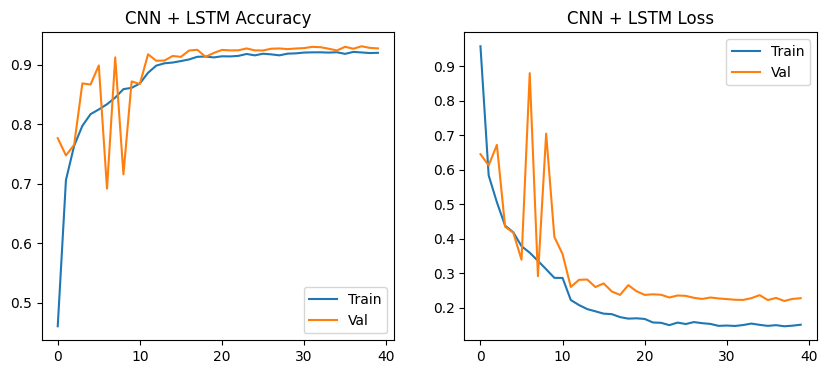

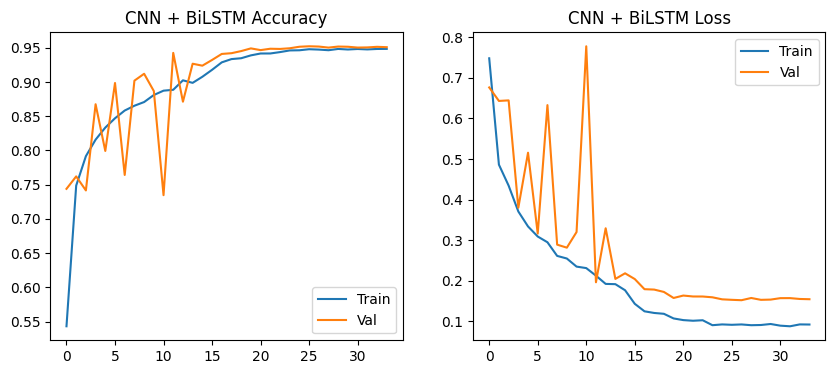

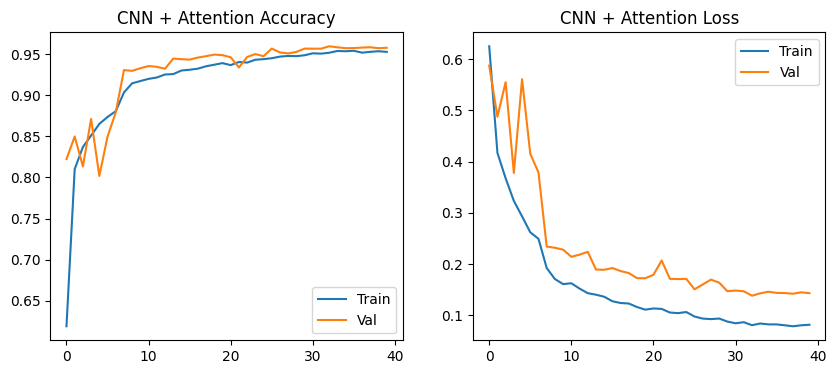

In [34]:
def plot_history(history, title):
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Accuracy')
    plt.legend(['Train', 'Val'])

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Loss')
    plt.legend(['Train', 'Val'])
    plt.show()

plot_history(history_lstm, "CNN + LSTM")
plot_history(history_bilstm, "CNN + BiLSTM")
plot_history(history_attention, "CNN + Attention")

In [35]:
results = pd.DataFrame({
    "Model": ["CNN+LSTM", "CNN+BiLSTM", "CNN+Attention"],
    "Accuracy": [lstm_acc, bilstm_acc, att_acc]
})

print(results)

           Model  Accuracy
0       CNN+LSTM  0.925445
1     CNN+BiLSTM  0.954134
2  CNN+Attention  0.960210


# CONFUSION MATRIX

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, title):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    classes = np.arange(cm.shape[0])
    plt.xticks(classes)
    plt.yticks(classes)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    # Add numbers inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center")

    plt.tight_layout()
    plt.show()

685/685 [==============================] - 13s 18ms/step


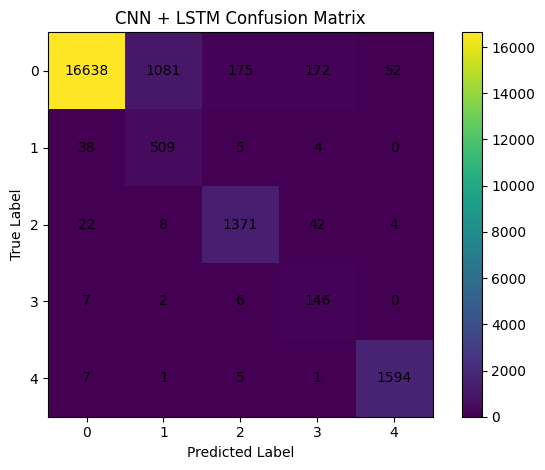

In [37]:
y_pred_lstm = np.argmax(model_lstm.predict(X_test), axis=1)
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plot_confusion_matrix(cm_lstm, "CNN + LSTM Confusion Matrix")

685/685 [==============================] - 17s 25ms/step


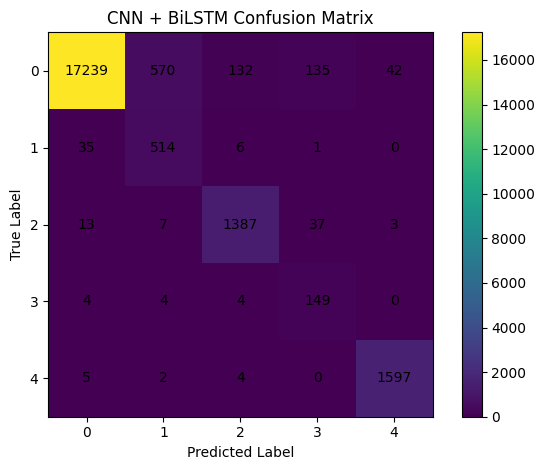

In [38]:
y_pred_bilstm = np.argmax(model_bilstm.predict(X_test), axis=1)
cm_bilstm = confusion_matrix(y_test, y_pred_bilstm)

plot_confusion_matrix(cm_bilstm, "CNN + BiLSTM Confusion Matrix")

685/685 [==============================] - 19s 28ms/step


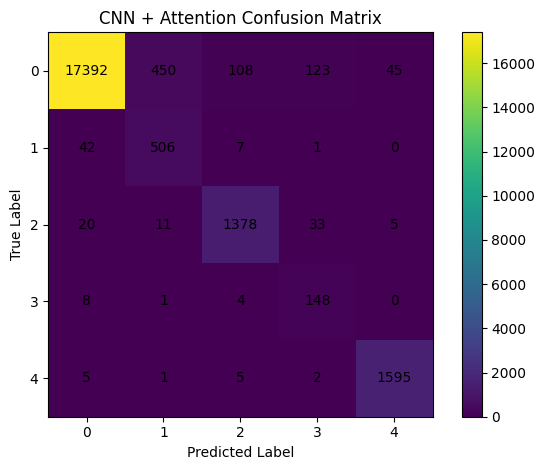

In [39]:
y_pred_att = np.argmax(model_attention.predict(X_test), axis=1)
cm_att = confusion_matrix(y_test, y_pred_att)

plot_confusion_matrix(cm_att, "CNN + Attention Confusion Matrix")

# ROC CURVE

In [40]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Number of classes
n_classes = 5

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])

# ---------- Function to compute ROC ----------
def compute_roc(model, X_test, y_test_bin):
    y_score = model.predict(X_test)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    return fpr, tpr, roc_auc

In [41]:
fpr_lstm, tpr_lstm, auc_lstm = compute_roc(model_lstm, X_test, y_test_bin)
fpr_bilstm, tpr_bilstm, auc_bilstm = compute_roc(model_bilstm, X_test, y_test_bin)
fpr_att, tpr_att, auc_att = compute_roc(model_attention, X_test, y_test_bin)

685/685 [==============================] - 18s 26ms/step


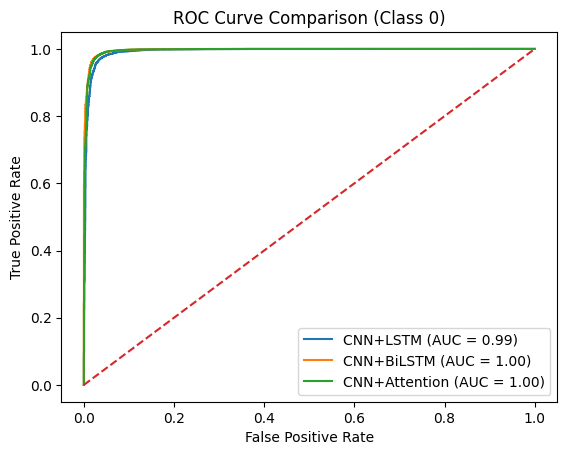

In [42]:
plt.figure()

# Plot for class 0 (you can change class index)
i = 0  

plt.plot(fpr_lstm[i], tpr_lstm[i],
         label=f'CNN+LSTM (AUC = {auc_lstm[i]:.2f})')

plt.plot(fpr_bilstm[i], tpr_bilstm[i],
         label=f'CNN+BiLSTM (AUC = {auc_bilstm[i]:.2f})')

plt.plot(fpr_att[i], tpr_att[i],
         label=f'CNN+Attention (AUC = {auc_att[i]:.2f})')

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Class 0)")
plt.legend()
plt.show()

In [43]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [44]:
import pandas as pd

df = pd.read_csv("mitbih_train.csv", header=None)

sample = df.iloc[75023, :-1].values
print(",".join(map(str, sample)))

0.4688524603843689,0.3540983498096466,0.25573769211769104,0.1688524633646011,0.049180328845977776,0.0,0.02295081876218319,0.04262294992804527,0.049180328845977776,0.07540983706712721,0.11311475187540054,0.13442623615264893,0.16557377576828003,0.19344262778759,0.20000000298023224,0.19180327653884888,0.19672131538391116,0.20000000298023224,0.20163933932781217,0.19344262778759,0.19180327653884888,0.20000000298023224,0.20163933932781217,0.19672131538391116,0.1983606517314911,0.20655737817287445,0.21639344096183777,0.21967212855815887,0.23278687894344327,0.25573769211769104,0.27540984749794006,0.2950819730758667,0.31803280115127563,0.34918034076690674,0.36557376384735113,0.37868851423263544,0.38196721673011774,0.38688525557518005,0.37704917788505554,0.3622950911521912,0.3393442630767822,0.3229508101940155,0.3081967234611511,0.2885245978832245,0.27213114500045776,0.2704918086528778,0.2573770582675934,0.24918033182621,0.24098360538482663,0.24426229298114777,0.24098360538482663,0.2393442690372

In [45]:
import pandas as pd

df = pd.read_csv("mitbih_test.csv", header=None)

sample = df.iloc[15000, :-1].values
print(",".join(map(str, sample)))

1.0,0.948924720287323,0.8279569745063781,0.7365591526031494,0.5067204236984253,0.22983871400356287,0.008064515888690947,0.0,0.0026881720405071974,0.025537634268403053,0.04838709533214569,0.07258064299821852,0.09139785170555113,0.10080645233392715,0.09811828285455704,0.09543010592460632,0.08870967477560043,0.0860215052962303,0.07392472773790358,0.07258064299821852,0.06451612710952759,0.06317204236984253,0.057795699685812,0.06182795763015747,0.06182795763015747,0.07392472773790358,0.07795698940753935,0.09408602118492126,0.10349462181329729,0.12231183052062988,0.13978494703769684,0.1666666716337204,0.18413978815078733,0.21370968222618103,0.23387096822261808,0.2594085931777954,0.2728494703769684,0.29032257199287415,0.29435482621192927,0.3051075339317322,0.3037634491920471,0.3091397881507873,0.30241936445236206,0.29973119497299194,0.28629031777381897,0.2849462330341339,0.2755376398563385,0.27016130089759827,0.2540322542190552,0.2620967626571655,0.25537633895874023,0.2594085931777954,0.25268

# MODEL COMPARISON

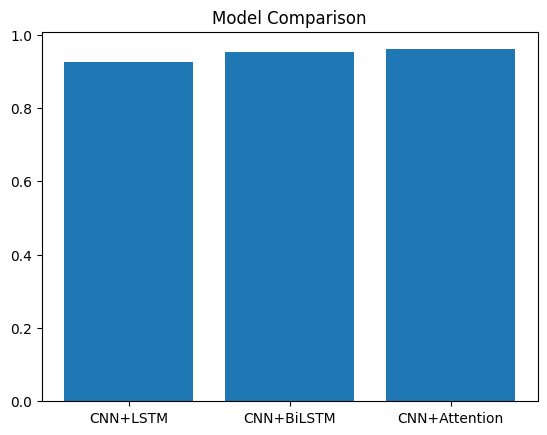

In [46]:
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Comparison")
plt.show()